In [ ]:
pip install requests pandas matplotlib seaborn

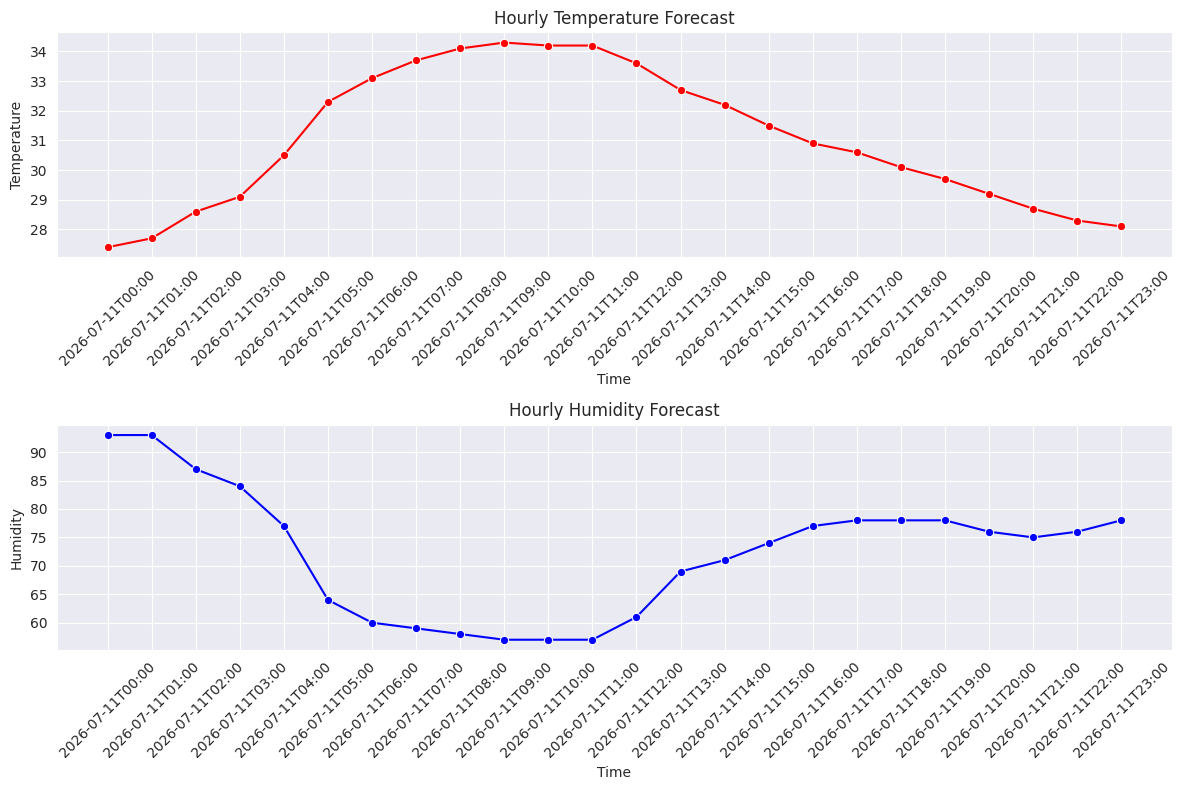

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Latitude and Longitude of Delhi
LAT = 28.6139
LON = 77.2090

# Open-Meteo API URL (No API Key Required)
url = (
    f"https://api.open-meteo.com/v1/forecast?"
    f"latitude={LAT}&longitude={LON}"
    f"&hourly=temperature_2m,relative_humidity_2m"
    f"&forecast_days=2"
)

# Fetch data
response = requests.get(url)

if response.status_code != 200:
    print("Failed to fetch data")
    exit()

data = response.json()

# Create DataFrame
df = pd.DataFrame({
    "Time": data["hourly"]["time"],
    "Temperature": data["hourly"]["temperature_2m"],
    "Humidity": data["hourly"]["relative_humidity_2m"]
})

# Keep first 24 hours
df = df.iloc[:24]

# Plot Dashboard
sns.set_style("darkgrid")

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Temperature Plot
sns.lineplot(
    x="Time",
    y="Temperature",
    data=df,
    marker="o",
    color="red",
    ax=axes[0]
)
axes[0].set_title("Hourly Temperature Forecast")
axes[0].tick_params(axis="x", rotation=45)

# Humidity Plot
sns.lineplot(
    x="Time",
    y="Humidity",
    data=df,
    marker="o",
    color="blue",
    ax=axes[1]
)
axes[1].set_title("Hourly Humidity Forecast")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()

# Save dashboard
plt.savefig("weather_dashboard.png", dpi=300)

# Show dashboard
plt.show()